# Progetto Machine Learning: Cupid's Algorithm

In questo notebook costruiamo un modello di **classificazione binaria** che prova a prevedere se due persone (Persona A e Persona B) sono **compatibili** oppure no, partendo dai loro dati anagrafici e dai loro tratti di personalità.

Il percorso è diviso in questi passaggi:

1. Importare i dati
2. Osservare il dataset
3. Training e Test (con creazione di nuove variabili)
4. Data Exploration
5. Data preprocessing e Pipeline di elaborazione
6. Definizione e Addestramento del modello
7. Validazione e risultati
8. Analisi degli errori
9. Ottimizzazione degli Iperparametri
10. Valutazione Finale sul Test Set
11. Curve Precision/Recall e soglia di decisione
12. Confronto con una Rete Neurale (MLP)
13. Valutazione finale comparativa


## 1. Importare i dati

Iniziamo preparando gli strumenti di lavoro: importiamo le librerie standard di Data
Science (Pandas, Seaborn, Matplotlib) e usiamo `kagglehub` per scaricare in automatico
l'ultima versione del dataset "Cupid's Algorithm" da Kaggle.

In [1]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scarichiamo l'ultima versione del dataset
path = kagglehub.dataset_download("likithagedipudi/cupids-algorithm")
print("Percorso del dataset:", path)

archivio = os.listdir(path)
print("File trovati:", archivio)

csv_path = os.path.join(path, archivio[0])

100%|██████████| 4.02M/4.02M [00:00<00:00, 136MB/s]

Extracting files...
Percorso del dataset: /root/.cache/kagglehub/datasets/likithagedipudi/cupids-algorithm/versions/1
File trovati: ['cupid_algorithm_dataset.csv']


**Cosa abbiamo ottenuto:** il dataset è stato scaricato correttamente e contiene un
unico file, `cupid_algorithm_dataset.csv`, che useremo per tutto il progetto.

## 2. Osservare il dataset

Prima di lavorare sul codice, diamo un'occhiata veloce alla struttura dei dati con
`.head()`. Questo ci permette di vedere i primi profili delle coppie (Persona A e
Persona B) e i loro tratti.

In [2]:
df = pd.read_csv(csv_path)
df.head()

,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68


**Cosa abbiamo ottenuto:** il dataset ha 30 colonne in totale, che includono dati
demografici (età, istruzione, luogo di residenza), tratti psicologici (apertura,
estroversione, gradevolezza, ecc.) sia per la Persona A che per la Persona B, e le
variabili che vogliamo prevedere (compatibilità, punteggio di compatibilità, durata
della relazione).

## 3. Training e Test

Seguendo le buone pratiche di Machine Learning, separiamo subito il 20% dei dati come
"Test Set", **prima** di fare qualsiasi altra elaborazione. Questo è fondamentale per
evitare il *Data Leakage*: il modello deve imparare solo dal Training Set e restare
all'oscuro dei dati di test fino alla valutazione finale.

Togliamo dalle variabili di input (`X`) l'identificativo della coppia (`pair_id`, che
non ha alcun significato predittivo) e le tre variabili che vogliamo prevedere. In
questo notebook usiamo solo il target di classificazione binaria (`compatible`); le
altre due variabili di regressione restano definite ma non vengono utilizzate più
avanti.

In [3]:
from sklearn.model_selection import train_test_split

# Rimuoviamo l'identificativo della coppia e le variabili che vogliamo prevedere
X = df.drop(["pair_id", "compatible", "compatibility_score", "relationship_longevity_months"], axis=1)

# Definiamo i target possibili (in questo notebook usiamo solo quello di classificazione)
y_classificazione = df["compatible"]
y_regressione_1 = df["compatibility_score"]
y_regressione_2 = df["relationship_longevity_months"]

# Separiamo il 20% dei dati come Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y_classificazione, test_size=0.2, random_state=42)

X_train.info()
y_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   a_age                       80000 non-null  int64  
 1   a_education                 80000 non-null  int64  
 2   a_location                  80000 non-null  object 
 3   a_career_field              80000 non-null  object 
 4   a_career_ambition           80000 non-null  float64
 5   a_openness                  80000 non-null  float64
 6   a_extraversion              80000 non-null  float64
 7   a_agreeableness             80000 non-null  float64
 8   a_conscientiousness         80000 non-null  float64
 9   a_chronotype                80000 non-null  float64
 10  a_spontaneity               80000 non-null  float64
 11  a_love_language             80000 non-null  object 
 12  a_emotional_expressiveness  80000 non-null  float64
 13  b_age                       8000

Abbiamo deciso di creare due nuove variabili a partire da quelle esistenti, per
aiutare il modello a "ragionare" in modo più simile a come farebbe una persona:

- **age_diff**: la differenza di età tra i due partner (il dataset penalizza le coppie
  con grandi differenze generazionali).
- **ambition_diff**: la differenza nel livello di ambizione professionale tra i due.

Calcoliamo queste variabili sia sul Training Set sia sul Test Set, usando sempre le
stesse formule, e poi lavoriamo su una copia del Training Set per non rischiare di
modificare per errore i dati originali.

In [4]:
# Creazione di nuove variabili (Feature Engineering)
X_train["age_diff"] = abs(X_train["a_age"] - X_train["b_age"])
X_test["age_diff"] = abs(X_test["a_age"] - X_test["b_age"])

X_train["ambition_diff"] = abs(X_train["a_career_ambition"] - X_train["b_career_ambition"])
X_test["ambition_diff"] = abs(X_test["a_career_ambition"] - X_test["b_career_ambition"])

# Lavoriamo su una copia del train set per non modificare per errore l'originale
cupid_class = X_train.copy()

**Cosa abbiamo ottenuto:** il Training Set contiene 80.000 coppie e, dopo aver
aggiunto le due nuove variabili, passiamo da 26 a 28 colonne di input.

## 4. Data Exploration

Analizziamo la qualità dei dati con `.info()` (per controllare valori mancanti) e
`.describe()` (per vedere i range, ad esempio le età vanno da 18 a 55 anni). Poi
usiamo grafici per capire meglio la forma dei dati: gli **istogrammi** mostrano come
si distribuisce ogni variabile, mentre la **matrice di correlazione** (heatmap) ci
mostra quali tratti sono legati tra loro.

In [5]:
cupid_class.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   a_age                       80000 non-null  int64  
 1   a_education                 80000 non-null  int64  
 2   a_location                  80000 non-null  object 
 3   a_career_field              80000 non-null  object 
 4   a_career_ambition           80000 non-null  float64
 5   a_openness                  80000 non-null  float64
 6   a_extraversion              80000 non-null  float64
 7   a_agreeableness             80000 non-null  float64
 8   a_conscientiousness         80000 non-null  float64
 9   a_chronotype                80000 non-null  float64
 10  a_spontaneity               80000 non-null  float64
 11  a_love_language             80000 non-null  object 
 12  a_emotional_expressiveness  80000 non-null  float64
 13  b_age                       8000

In [6]:
cupid_class.describe()

,a_age,a_education,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,a_emotional_expressiveness,...,b_career_ambition,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_emotional_expressiveness,age_diff,ambition_diff
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,36.554075,2.951087,0.496328,0.499946,0.499847,0.500735,0.498768,0.499447,0.500225,0.499566,...,0.496005,0.499696,0.499509,0.499343,0.499967,0.500450,0.500383,0.500294,12.650263,0.198389
std,10.965604,1.117647,0.175067,0.223542,0.224494,0.224002,0.223235,0.224856,0.226442,0.226323,...,0.174702,0.223644,0.224236,0.223177,0.223157,0.224091,0.226650,0.225733,8.953704,0.147380
min,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,2.000000,0.370000,0.330000,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,...,0.370000,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,0.330000,5.000000,0.080000
50%,37.000000,3.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,11.000000,0.170000
75%,46.000000,4.000000,0.620000,0.670000,0.670000,0.670000,0.670000,0.670000,0.680000,0.670000,...,0.620000,0.670000,0.670000,0.670000,0.670000,0.670000,0.670000,0.670000,19.000000,0.290000
max,55.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,37.000000,0.920000


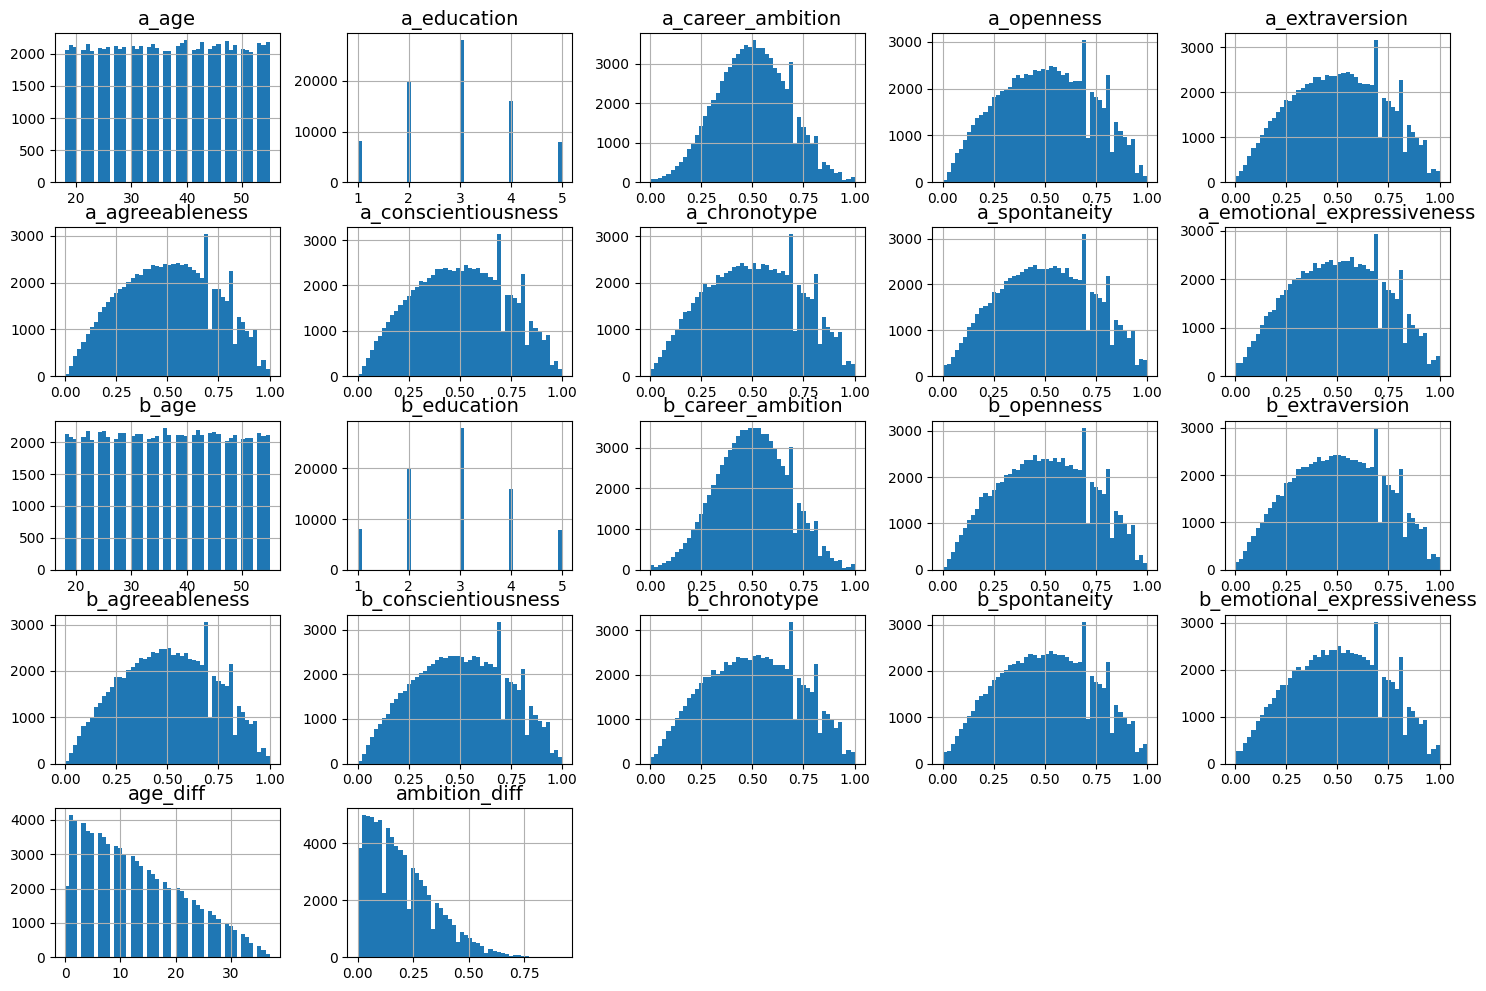

In [7]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

cupid_class.hist(bins=50, figsize=(18, 12))
plt.show()

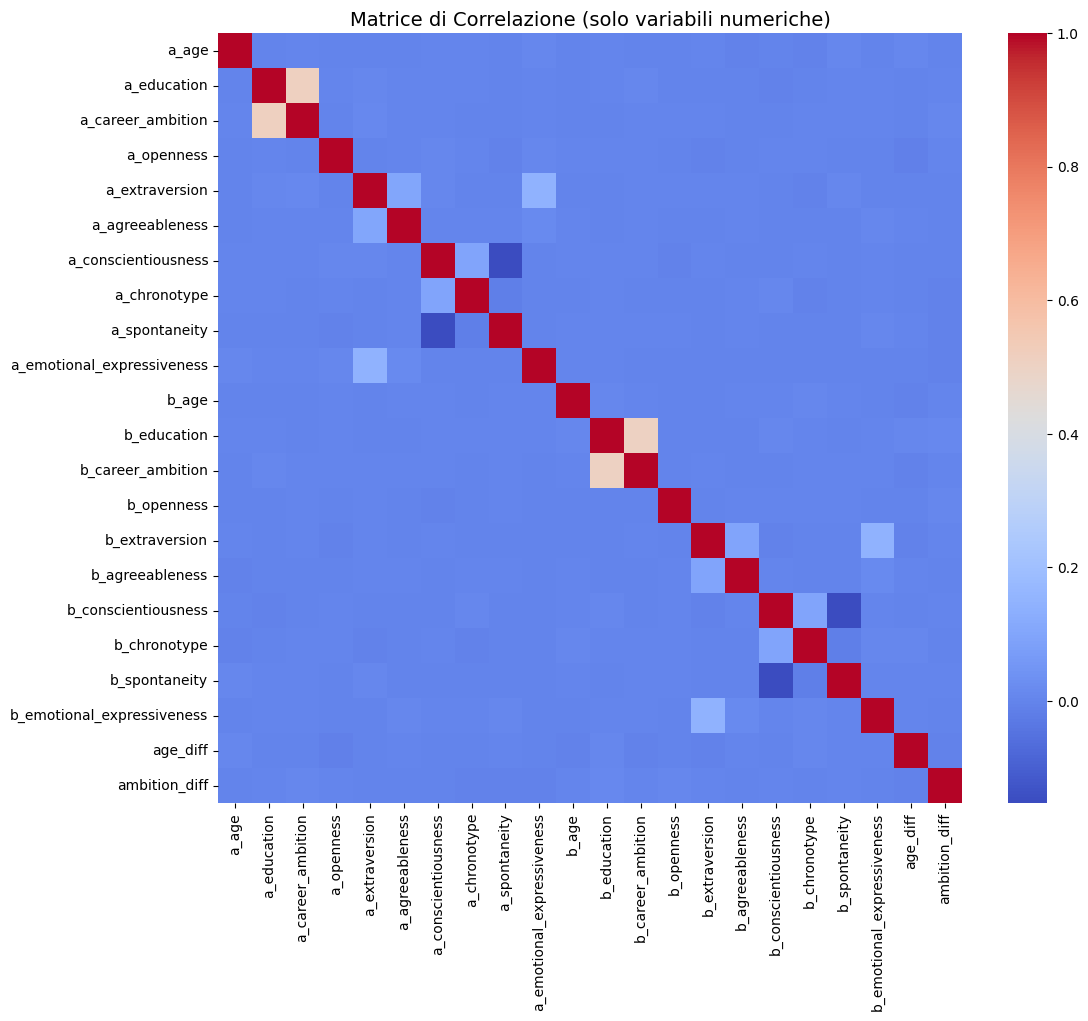

In [8]:
corr_matrix = cupid_class.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Matrice di Correlazione (solo variabili numeriche)")
plt.show()

**Cosa abbiamo ottenuto:** non ci sono valori mancanti in nessuna colonna. Le
variabili numeriche (età, tratti di personalità) hanno distribuzioni abbastanza
uniformi o a campana, senza valori anomali evidenti. La heatmap ci mostra correlazioni
basse tra la maggior parte delle variabili: questo è positivo, perché conferma che i
dati non nascondono "scorciatoie" sospette che il modello potrebbe sfruttare in modo
scorretto (correlazioni spurie), e che i dati seguono una logica psicologica
plausibile.

## 5. Data preprocessing e Pipeline di elaborazione

I modelli di Machine Learning hanno bisogno che i dati siano tutti in un formato
numerico e su scale simili. Per questo prepariamo una `ColumnTransformer` che applica:

- **StandardScaler** alle variabili numeriche (età, tratti di personalità, ecc.), per
  portarle tutte sulla stessa scala.
- **OneHotEncoder** alle variabili testuali (come il luogo di residenza o il tipo di
  lavoro), per trasformarle in colonne numeriche binarie (0/1).

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = [
    "a_age", "a_education", "a_career_ambition",
    "a_openness", "a_extraversion", "a_agreeableness", "a_conscientiousness",
    "a_chronotype", "a_spontaneity", "a_emotional_expressiveness",
    "b_age", "b_education", "b_career_ambition",
    "b_openness", "b_extraversion", "b_agreeableness", "b_conscientiousness",
    "b_chronotype", "b_spontaneity", "b_emotional_expressiveness",
    "age_diff", "ambition_diff"
]

cat_features = [
    "a_location", "a_career_field", "a_love_language",
    "b_location", "b_career_field", "b_love_language"
]

preprocessing = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

cupid_class_prepared = preprocessing.fit_transform(cupid_class)

# Ricostruiamo un DataFrame solo per controllare visivamente il risultato
cupid_class_prepared_df = pd.DataFrame(
    cupid_class_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=cupid_class.index
)
cupid_class_prepared_df.head(2)

,num__a_age,num__a_education,num__a_career_ambition,num__a_openness,num__a_extraversion,num__a_agreeableness,num__a_conscientiousness,num__a_chronotype,num__a_spontaneity,num__a_emotional_expressiveness,...,cat__b_career_field_Healthcare,cat__b_career_field_Law,cat__b_career_field_Marketing,cat__b_career_field_Science,cat__b_career_field_Tech,cat__b_love_language_Acts of Service,cat__b_love_language_Physical Touch,cat__b_love_language_Quality Time,cat__b_love_language_Receiving Gifts,cat__b_love_language_Words of Affirmation
75220,-1.600841,0.938506,-0.550240,-0.044492,1.069760,-0.092568,0.587869,-1.287262,-1.414173,0.090288,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48955,-1.600841,-0.850978,0.649312,1.431750,-1.068394,0.621715,-0.084073,0.669557,-0.310128,-1.898037,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


**Cosa abbiamo ottenuto:** dopo la trasformazione, le 28 colonne originali
diventano 58 colonne. L'aumento è dovuto all'OneHotEncoder, che trasforma ogni
categoria delle variabili testuali (luogo, lavoro, linguaggio dell'amore) in una
colonna separata.

## 6. Definizione e Addestramento del Modello

Come primo modello abbiamo scelto il **Random Forest Classifier**: un algoritmo
basato su tante "foreste" di alberi decisionali, molto efficace per gestire dati
complessi e un po' rumorosi come quelli della compatibilità umana.

Costruiamo una `Pipeline` che unisce in un unico oggetto il preprocessing (che
abbiamo definito sopra) e il classificatore, così da poter applicare tutti i passaggi
in un solo comando, sia in fase di addestramento sia in fase di previsione.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# "prep" applica il ColumnTransformer definito prima
# "classifier" è il nostro Random Forest
clf_pipeline = Pipeline([
    ("prep", preprocessing),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

clf_pipeline.fit(X_train, y_train)
print("Modello Random Forest addestrato!")

Modello Random Forest addestrato!


**Cosa abbiamo ottenuto:** il modello si allena senza errori sull'intero Training
Set (80.000 coppie).

## 7. Validazione e Risultati (F1-Score)

Valutiamo la bontà del modello con la **Cross Validation**: invece di allenare e
testare una sola volta, dividiamo il Training Set in 3 parti e ripetiamo il processo
3 volte, in modo da avere una stima più affidabile.

Invece di guardare solo l'accuratezza (che con classi sbilanciate può ingannare),
usiamo l'**F1-Score**, che bilancia correttamente i falsi positivi e i falsi
negativi.

In [11]:
from sklearn.model_selection import cross_val_score

scores_rf = cross_val_score(clf_pipeline, X_train, y_train, cv=3, scoring="f1")
print(f"F1-Score medio Random Forest: {scores_rf.mean():.4f}")

F1-Score medio Random Forest: 0.4939


**Cosa abbiamo ottenuto:** un F1-Score medio di circa **0.49**. Non è un
risultato eccellente, ma è ragionevole: ci dice che il modello ha imparato a
riconoscere alcuni pattern reali nei dati, pur senza riuscire a prevedere la
compatibilità in modo molto preciso — cosa comprensibile, dato che il dataset include
del rumore intenzionale per simulare l'imprevedibilità delle relazioni umane.

## 8. Analisi degli Errori (Matrice di Confusione)

Guardiamo ora la **Matrice di Confusione**, che ci dice nel dettaglio quante volte il
modello ha indovinato e quante volte si è sbagliato (ad esempio scambiando una coppia
non compatibile per una compatibile, o viceversa). Calcoliamo anche **Precisione**,
**Recall** e **F1-Score** per capire meglio il tipo di errori che il modello
commette.

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Previsioni ottenute tramite cross validation (dati mai "visti" durante ogni singolo fold)
y_train_pred = cross_val_predict(clf_pipeline, X_train, y_train, cv=3)

cm = confusion_matrix(y_train, y_train_pred)
print("Matrice di confusione:")
print(cm)

precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print(f"\nPrecisione: {precision:.4f} (quanto è affidabile il modello quando dice che una coppia è compatibile)")
print(f"Recall: {recall:.4f} (quante coppie realmente compatibili sono state individuate)")
print(f"F1-Score: {f1:.4f} (equilibrio tra precisione e recall)")

Matrice di confusione:
[[37138  8546]
 [20261 14055]]

Precisione: 0.6219 (quanto è affidabile il modello quando dice che una coppia è compatibile)
Recall: 0.4096 (quante coppie realmente compatibili sono state individuate)
F1-Score: 0.4939 (equilibrio tra precisione e recall)


**Cosa abbiamo ottenuto:** una precisione di circa **0.62** e un recall di circa
**0.41** (F1 = 0.49, coerente con il punto precedente). Questo significa che il
modello è piuttosto **cauto**: quando dice che una coppia è compatibile ha ragione
circa 6 volte su 10, ma perde per strada molte coppie che in realtà erano compatibili
(ne individua solo circa 4 su 10). Questo comportamento è coerente con il rumore
aggiunto intenzionalmente nel dataset, che rende molto difficile prevedere con
certezza l'attrazione umana.

## 9. Ottimizzazione degli Iperparametri (GridSearchCV)

Per non scegliere la configurazione del modello "a occhio", usiamo `GridSearchCV`.
Questo strumento prova sistematicamente diverse combinazioni di parametri (numero di
alberi, profondità massima, gestione dello sbilanciamento delle classi) e misura la
loro efficacia tramite Cross Validation, così da trovare la combinazione che
massimizza l'F1-Score.

Per velocizzare la ricerca, la eseguiamo su un campione casuale pari al 15% del
Training Set, invece che sull'intero set di 80.000 righe.

In [13]:
from sklearn.model_selection import GridSearchCV

X_train_sample = X_train.sample(frac=0.15, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]
print(f"Dataset ridotto temporaneamente da {len(X_train)} a {len(X_train_sample)} righe, per velocizzare la ricerca.")

param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [12, None],
    "classifier__class_weight": ["balanced"]
}

grid_search = GridSearchCV(
    clf_pipeline,
    param_grid,
    cv=3,
    scoring="f1",
    verbose=1,
    n_jobs=1
)

print("Ricerca della configurazione migliore in corso...")
grid_search.fit(X_train_sample, y_train_sample)

best_model = grid_search.best_estimator_
print(f"Configurazione vincente: {grid_search.best_params_}")

Dataset ridotto temporaneamente da 80000 a 12000 righe, per velocizzare la ricerca.
Ricerca della configurazione migliore in corso...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Configurazione vincente: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 12, 'classifier__n_estimators': 50}


**Cosa abbiamo ottenuto:** `GridSearchCV` ha provato tutte le combinazioni
possibili tra i valori indicati nella griglia — 2 opzioni per il numero di alberi
(50 o 100), 2 opzioni per la profondità massima (12 o "senza limite"), ripetendo ogni
combinazione su 3 fold — e ha selezionato quella con l'F1-Score migliore. Il risultato
esatto viene mostrato dalla stampa `grid_search.best_params_` qui sopra.

## 10. Valutazione Finale sul Test Set

Usiamo ora il modello migliore trovato da `GridSearchCV` per fare previsioni sui dati
del Test Set, che l'algoritmo non ha mai visto durante l'addestramento. Questo è il
test più realistico di quanto il modello sia davvero affidabile.

F1-Score finale sul Test Set: 0.5622


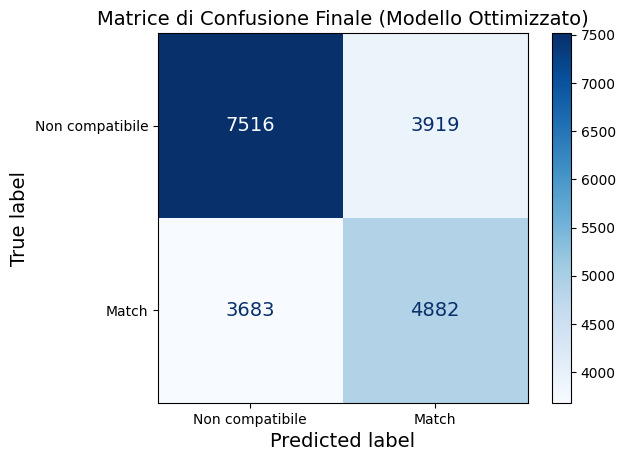

In [14]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

y_test_pred = best_model.predict(X_test)

f1_final = f1_score(y_test, y_test_pred)
print(f"F1-Score finale sul Test Set: {f1_final:.4f}")

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non compatibile", "Match"]).plot(cmap="Blues")
plt.title("Matrice di Confusione Finale (Modello Ottimizzato)")
plt.show()

**Cosa abbiamo ottenuto:** un F1-Score finale di circa **0.56** sul Test Set,
migliore rispetto allo 0.49 ottenuto in Cross Validation prima dell'ottimizzazione.
Questo conferma che la ricerca degli iperparametri ha effettivamente aiutato il
modello a generalizzare meglio su dati nuovi. Il punteggio resta comunque moderato,
in linea con la natura "rumorosa" del dataset: prevedere con certezza l'attrazione
umana è per sua natura difficile.

## 11. Curve Precision/Recall

Finora abbiamo sempre usato la soglia di decisione predefinita (0.5): se la
probabilità stimata di compatibilità supera 0.5, il modello dice "compatibile",
altrimenti "non compatibile". Ma questa soglia si può cambiare, a seconda di cosa ci
interessa di più: essere molto sicuri quando diciamo "compatibile" (precisione alta)
oppure non perdere nessuna coppia potenzialmente valida (recall alto).

Per esplorare questo compromesso, otteniamo prima le probabilità stimate dal modello
(invece delle sole etichette 0/1), poi calcoliamo precisione e recall al variare
della soglia.

In [15]:
# Otteniamo le probabilità stimate sul Training Set (tramite cross validation)
y_probas = cross_val_predict(best_model, X_train, y_train, cv=3, method="predict_proba")

# Teniamo solo la probabilità della classe positiva ("compatibile")
y_scores = y_probas[:, 1]

print("Prime 5 probabilità di compatibilità stimate:")
print(y_scores[:5])

Prime 5 probabilità di compatibilità stimate:
[0.64289073 0.48979757 0.45248187 0.45507775 0.47395057]


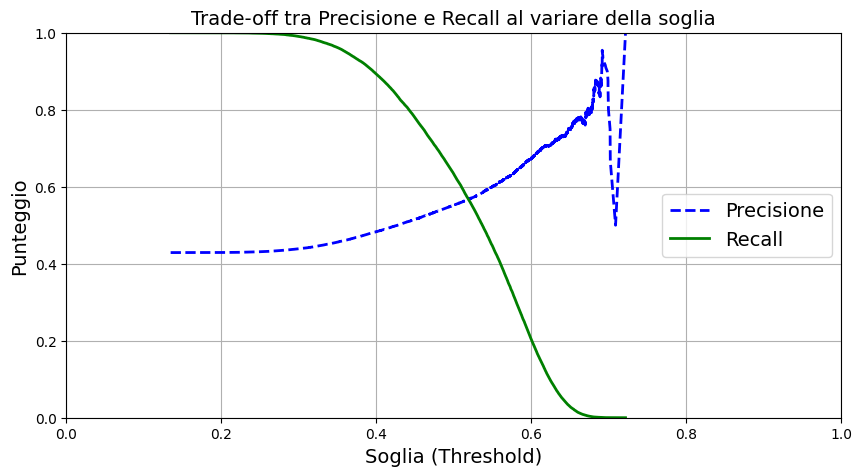

In [16]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precisione", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Soglia (Threshold)")
plt.ylabel("Punteggio")
plt.title("Trade-off tra Precisione e Recall al variare della soglia")
plt.legend(loc="center right")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.show()

**Cosa abbiamo ottenuto:** il grafico mostra chiaramente il compromesso: quando
alziamo la soglia, la precisione sale (il modello diventa più "esigente" e si sbaglia
meno quando dice "compatibile"), ma il recall scende (il modello individua sempre meno
coppie compatibili reali). Non esiste una soglia "giusta" in assoluto: la scelta
dipende da cosa conta di più per l'uso finale del modello.

### Cosa cambia se fissiamo la precisione minima al 70%

Quando il sistema segnala una coppia come compatibile, vogliamo avere ragione almeno 7 volte su
10. Cerchiamo quindi la soglia più bassa che garantisce questa precisione, e
osserviamo quale recall ne deriva.

In [17]:
import numpy as np

precisione_desiderata = 0.70

# Cerchiamo il primo indice in cui la precisione raggiunge il valore desiderato
idx_threshold_ottimo = np.argmax(precisions >= precisione_desiderata)
threshold_ottimo = thresholds[idx_threshold_ottimo]
recall_associato = recalls[idx_threshold_ottimo]

print(f"Per ottenere una precisione del {precisione_desiderata*100:.0f}%, la soglia deve essere: {threshold_ottimo:.4f}")
print(f"Con questa soglia, il recall sarebbe solo del {recall_associato*100:.2f}% (percentuale di coppie realmente compatibili individuate)")

Per ottenere una precisione del 70%, la soglia deve essere: 0.6140
Con questa soglia, il recall sarebbe solo del 14.05% (percentuale di coppie realmente compatibili individuate)


**Cosa abbiamo ottenuto:** per arrivare al 70% di precisione bisogna alzare la
soglia fino a circa **0.61**, ma il prezzo da pagare è molto alto: il recall crolla al
**14%** circa. In pratica, il modello diventerebbe così prudente da segnalare come
"compatibili" solo pochissime coppie, perdendone per strada moltissime altre che
probabilmente lo erano davvero. Questo esempio mostra bene perché la scelta della
soglia va sempre valutata insieme a chi userà il modello, e non decisa isolatamente
guardando una sola metrica.

## 12. Confronto con una Rete Neurale (MLP)

Proviamo ora un secondo tipo di modello, un **Multi-Layer Perceptron** (una rete neurale),
per vedere se riesce a cogliere meglio eventuali relazioni non lineari
tra le variabili. Costruiamo una pipeline analoga a quella del Random Forest,
riutilizzando lo stesso preprocessing, e calcoliamo le probabilità stimate sul
Training Set con la stessa procedura di cross validation usata sopra, così da poter
confrontare le curve dei due modelli.

In [18]:
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ("prep", preprocessing),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42
    ))
])

print("Calcolo delle probabilità del MLP sul Training Set (cross validation)...")
y_probas_mlp = cross_val_predict(mlp_pipeline, X_train, y_train, cv=3, method="predict_proba")
y_scores_mlp = y_probas_mlp[:, 1]
print("Fatto.")

Calcolo delle probabilità del MLP sul Training Set (cross validation)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Fatto.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


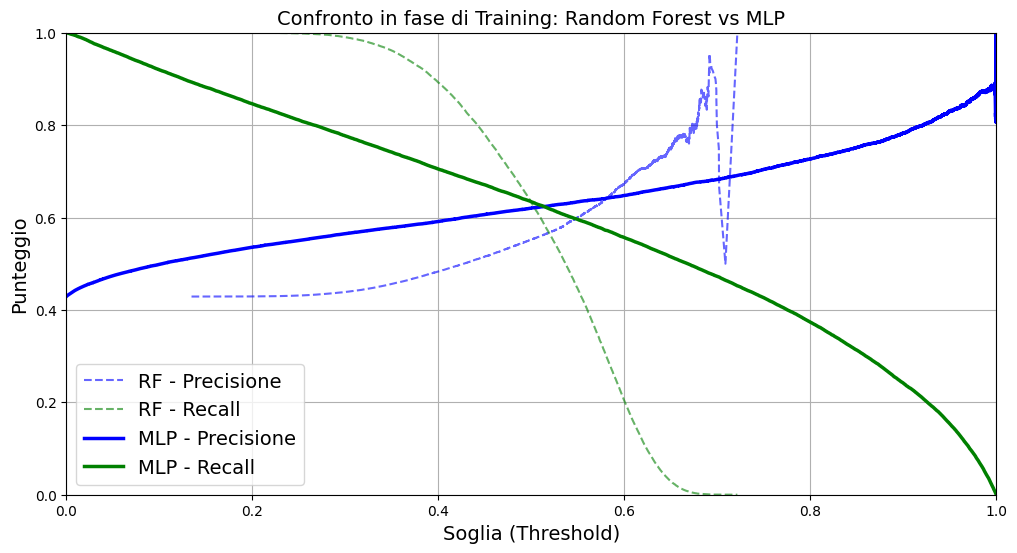

In [19]:
precisions_mlp, recalls_mlp, thresholds_mlp = precision_recall_curve(y_train, y_scores_mlp)

plt.figure(figsize=(12, 6))

# Curve del Random Forest ottimizzato (linee tratteggiate)
plt.plot(thresholds, precisions[:-1], "b--", label="RF - Precisione", alpha=0.6)
plt.plot(thresholds, recalls[:-1], "g--", label="RF - Recall", alpha=0.6)

# Curve del nuovo MLP (linee continue)
plt.plot(thresholds_mlp, precisions_mlp[:-1], "b-", label="MLP - Precisione", linewidth=2.5)
plt.plot(thresholds_mlp, recalls_mlp[:-1], "g-", label="MLP - Recall", linewidth=2.5)

plt.xlabel("Soglia (Threshold)")
plt.ylabel("Punteggio")
plt.title("Confronto in fase di Training: Random Forest vs MLP")
plt.legend(loc="lower left")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.show()

**Cosa abbiamo ottenuto:** guardando le curve sul Training Set, l'MLP mostra un
comportamento più stabile e regolare rispetto al Random Forest lungo gran parte delle
soglie, un primo indizio che questa rete neurale potrebbe generalizzare meglio. Per
avere una risposta definitiva, però, dobbiamo confrontare i due modelli sul Test Set,
che è quello che facciamo nel prossimo passaggio.

## 13. Valutazione Finale Comparativa: Random Forest vs MLP

Confrontiamo ora davvero i due modelli sul Test Set (dati mai visti). Alleniamo l'MLP
sull'intero Training Set (finora lo avevamo usato solo tramite cross validation) e
applichiamo a entrambi i modelli una soglia vicina a 0.5, scelta osservando il punto
di incrocio tra le curve di precisione e recall viste sopra (0.55 per il Random
Forest, 0.54 per l'MLP).

--- VALUTAZIONE FINALE SUL TEST SET ---
Random Forest (soglia 0.55):
  Precisione: 0.6011
  Recall:     0.3950
  F1-Score:   0.4767

MLP / Rete Neurale (soglia 0.54):
  Precisione: 0.6792
  Recall:     0.5643
  F1-Score:   0.6164



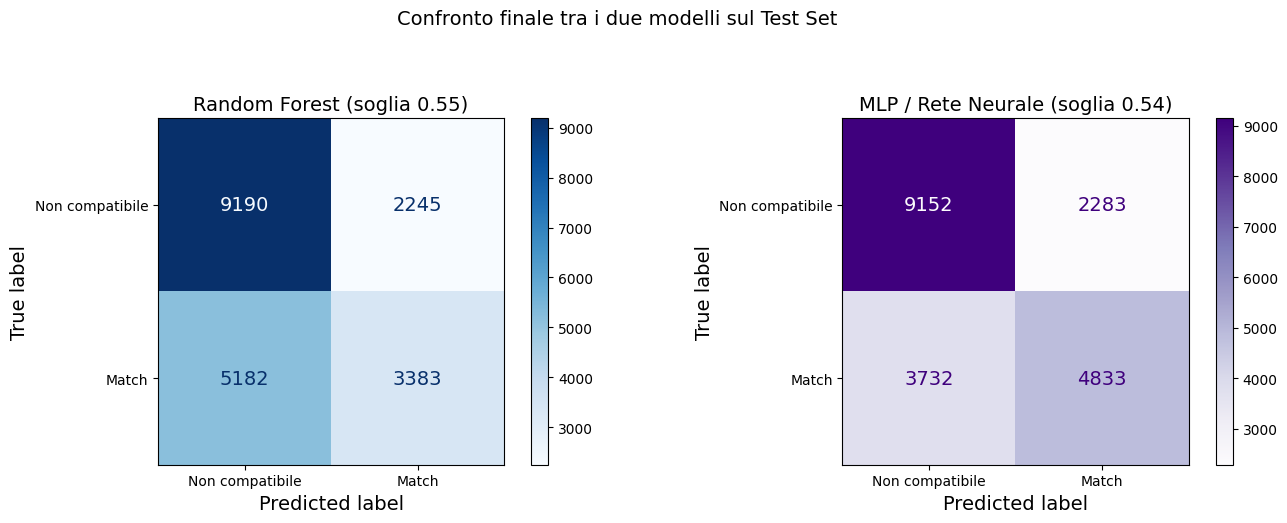

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Random Forest ottimizzato, soglia 0.55
probas_test_rf = best_model.predict_proba(X_test)[:, 1]
y_test_pred_rf = (probas_test_rf >= 0.55)

# MLP: lo alleniamo sull'intero Training Set
mlp_pipeline.fit(X_train, y_train)
probas_test_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]
y_test_pred_mlp = (probas_test_mlp >= 0.54)

print("--- VALUTAZIONE FINALE SUL TEST SET ---")
print("Random Forest (soglia 0.55):")
print(f"  Precisione: {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"  Recall:     {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"  F1-Score:   {f1_score(y_test, y_test_pred_rf):.4f}\n")

print("MLP / Rete Neurale (soglia 0.54):")
print(f"  Precisione: {precision_score(y_test, y_test_pred_mlp):.4f}")
print(f"  Recall:     {recall_score(y_test, y_test_pred_mlp):.4f}")
print(f"  F1-Score:   {f1_score(y_test, y_test_pred_mlp):.4f}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Non compatibile", "Match"]).plot(
    ax=axes[0], cmap="Blues", values_format="d"
)
axes[0].set_title("Random Forest (soglia 0.55)")

cm_mlp = confusion_matrix(y_test, y_test_pred_mlp)
ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=["Non compatibile", "Match"]).plot(
    ax=axes[1], cmap="Purples", values_format="d"
)
axes[1].set_title("MLP / Rete Neurale (soglia 0.54)")

plt.suptitle("Confronto finale tra i due modelli sul Test Set", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

**Cosa abbiamo ottenuto:** sul Test Set, l'MLP batte il Random Forest su tutte e
tre le metriche:

| Modello | Precisione | Recall | F1-Score |
|---|---|---|---|
| Random Forest (soglia 0.55) | 0.60 | 0.40 | 0.48 |
| MLP / Rete Neurale (soglia 0.54) | 0.68 | 0.56 | 0.62 |

La rete neurale riesce a individuare molte più coppie realmente compatibili (recall
più alto) mantenendo comunque una precisione migliore. Questo suggerisce che le
relazioni tra le variabili di questo dataset non sono del tutto lineari, e un modello
come l'MLP, capace di catturare interazioni più complesse, riesce a sfruttarle meglio.

**Conclusione generale del progetto:** siamo partiti da un Random Forest di base
(F1 ≈ 0.49 in cross validation), lo abbiamo migliorato con la ricerca degli
iperparametri (F1 ≈ 0.56 sul Test Set) e infine lo abbiamo confrontato con una rete
neurale, che si è rivelata il modello più efficace (F1 ≈ 0.62 sul Test Set). In tutti
i casi i punteggi restano moderati e non altissimi: questo è coerente con il fatto che
il dataset contiene rumore aggiunto intenzionalmente per simulare l'imprevedibilità
reale delle relazioni umane, quindi va interpretato come un limite dei dati più che
del modello.

Alcuni limiti da tenere presente e possibili miglioramenti futuri:
- l'MLP non è mai stato ottimizzato con una ricerca sistematica degli iperparametri
  (come invece è stato fatto per il Random Forest con `GridSearchCV`): probabilmente
  potrebbe migliorare ulteriormente;
- le soglie di decisione (0.55 e 0.54) sono state scelte osservando i grafici, non
  con una procedura sistematica identica per entrambi i modelli;
- si potrebbero esplorare altri algoritmi (ad esempio Gradient Boosting) o tecniche di
  bilanciamento delle classi più sofisticate per provare a migliorare ulteriormente
  il recall senza sacrificare troppo la precisione.